In [1]:
import sys
from pathlib import Path

# Thêm thư mục gốc vào hệ thống tìm kiếm của Python
sys.path.append(str(Path.cwd().parent))

#Bây giờ mới có thể gọi file paths.py, 
#Lưu ý import đúng đường dẫn muốn dùng và đã được định nghĩa ở file path.py
from src.path import  DATA_RAW_FILE,check_and_create_directories
# Lưu ý biến auto_create( biến trạng thái ) dùng để tự tạo thư mục nếu chưa tồn tại
# Chỉnh lại True nếu cần xuất reports,figure,data_reports,models weight đọc tài liệu, path.py trước khi dùng
check_and_create_directories(auto_create=False)

✅ Tất cả các thư mục cấu trúc dự án đã đầy đủ và sẵn sàng!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder  

# Thiết lập phong cách hiển thị chung cho toàn bộ biểu đồ (Clean & Professional)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0}) # Tắt cảnh báo khi vẽ nhiều hình

In [3]:
df = pd.read_csv(DATA_RAW_FILE)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# 1. Làm sạch Total Charges: ép về numeric và điền NaN bằng 0
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# 2. Xóa cột định danh không cần thiết để tránh lỗi string
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

# 3. Chuyển đổi tất cả các cột object (chữ) còn lại về số (int) ngay trên df gốc
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [6]:
df.describe()

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043.0,7043.0,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,0.0,0.0,593.713616,93521.964646,793.535567,36.282441,-119.798880,0.504756,0.162147,...,0.690473,0.592219,1.574329,64.761692,2279.734304,0.265370,0.265370,58.699418,4400.295755,16.712338
std,0.0,0.0,0.0,314.990288,1865.794555,480.597035,2.455723,2.157889,0.500013,0.368612,...,0.833755,0.491457,1.068104,30.090047,2266.794470,0.441561,0.441561,21.525131,1183.057152,6.294320
min,1.0,0.0,0.0,0.000000,90001.000000,0.000000,32.555828,-124.301372,0.000000,0.000000,...,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,5.000000,2003.000000,0.000000
25%,1.0,0.0,0.0,337.000000,92102.000000,376.000000,34.030915,-121.815412,0.000000,0.000000,...,0.000000,0.000000,1.000000,35.500000,398.550000,0.000000,0.000000,40.000000,3469.000000,18.000000
50%,1.0,0.0,0.0,601.000000,93552.000000,771.000000,36.391777,-119.730885,1.000000,0.000000,...,0.000000,1.000000,2.000000,70.350000,1394.550000,0.000000,0.000000,61.000000,4527.000000,20.000000
75%,1.0,0.0,0.0,869.000000,95351.000000,1211.000000,38.224869,-118.043237,1.000000,0.000000,...,1.000000,1.000000,2.000000,89.850000,3786.600000,1.000000,1.000000,75.000000,5380.500000,20.000000
max,1.0,0.0,0.0,1128.000000,96161.000000,1651.000000,41.962127,-114.192901,1.000000,1.000000,...,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000,1.000000,100.000000,6500.000000,20.000000


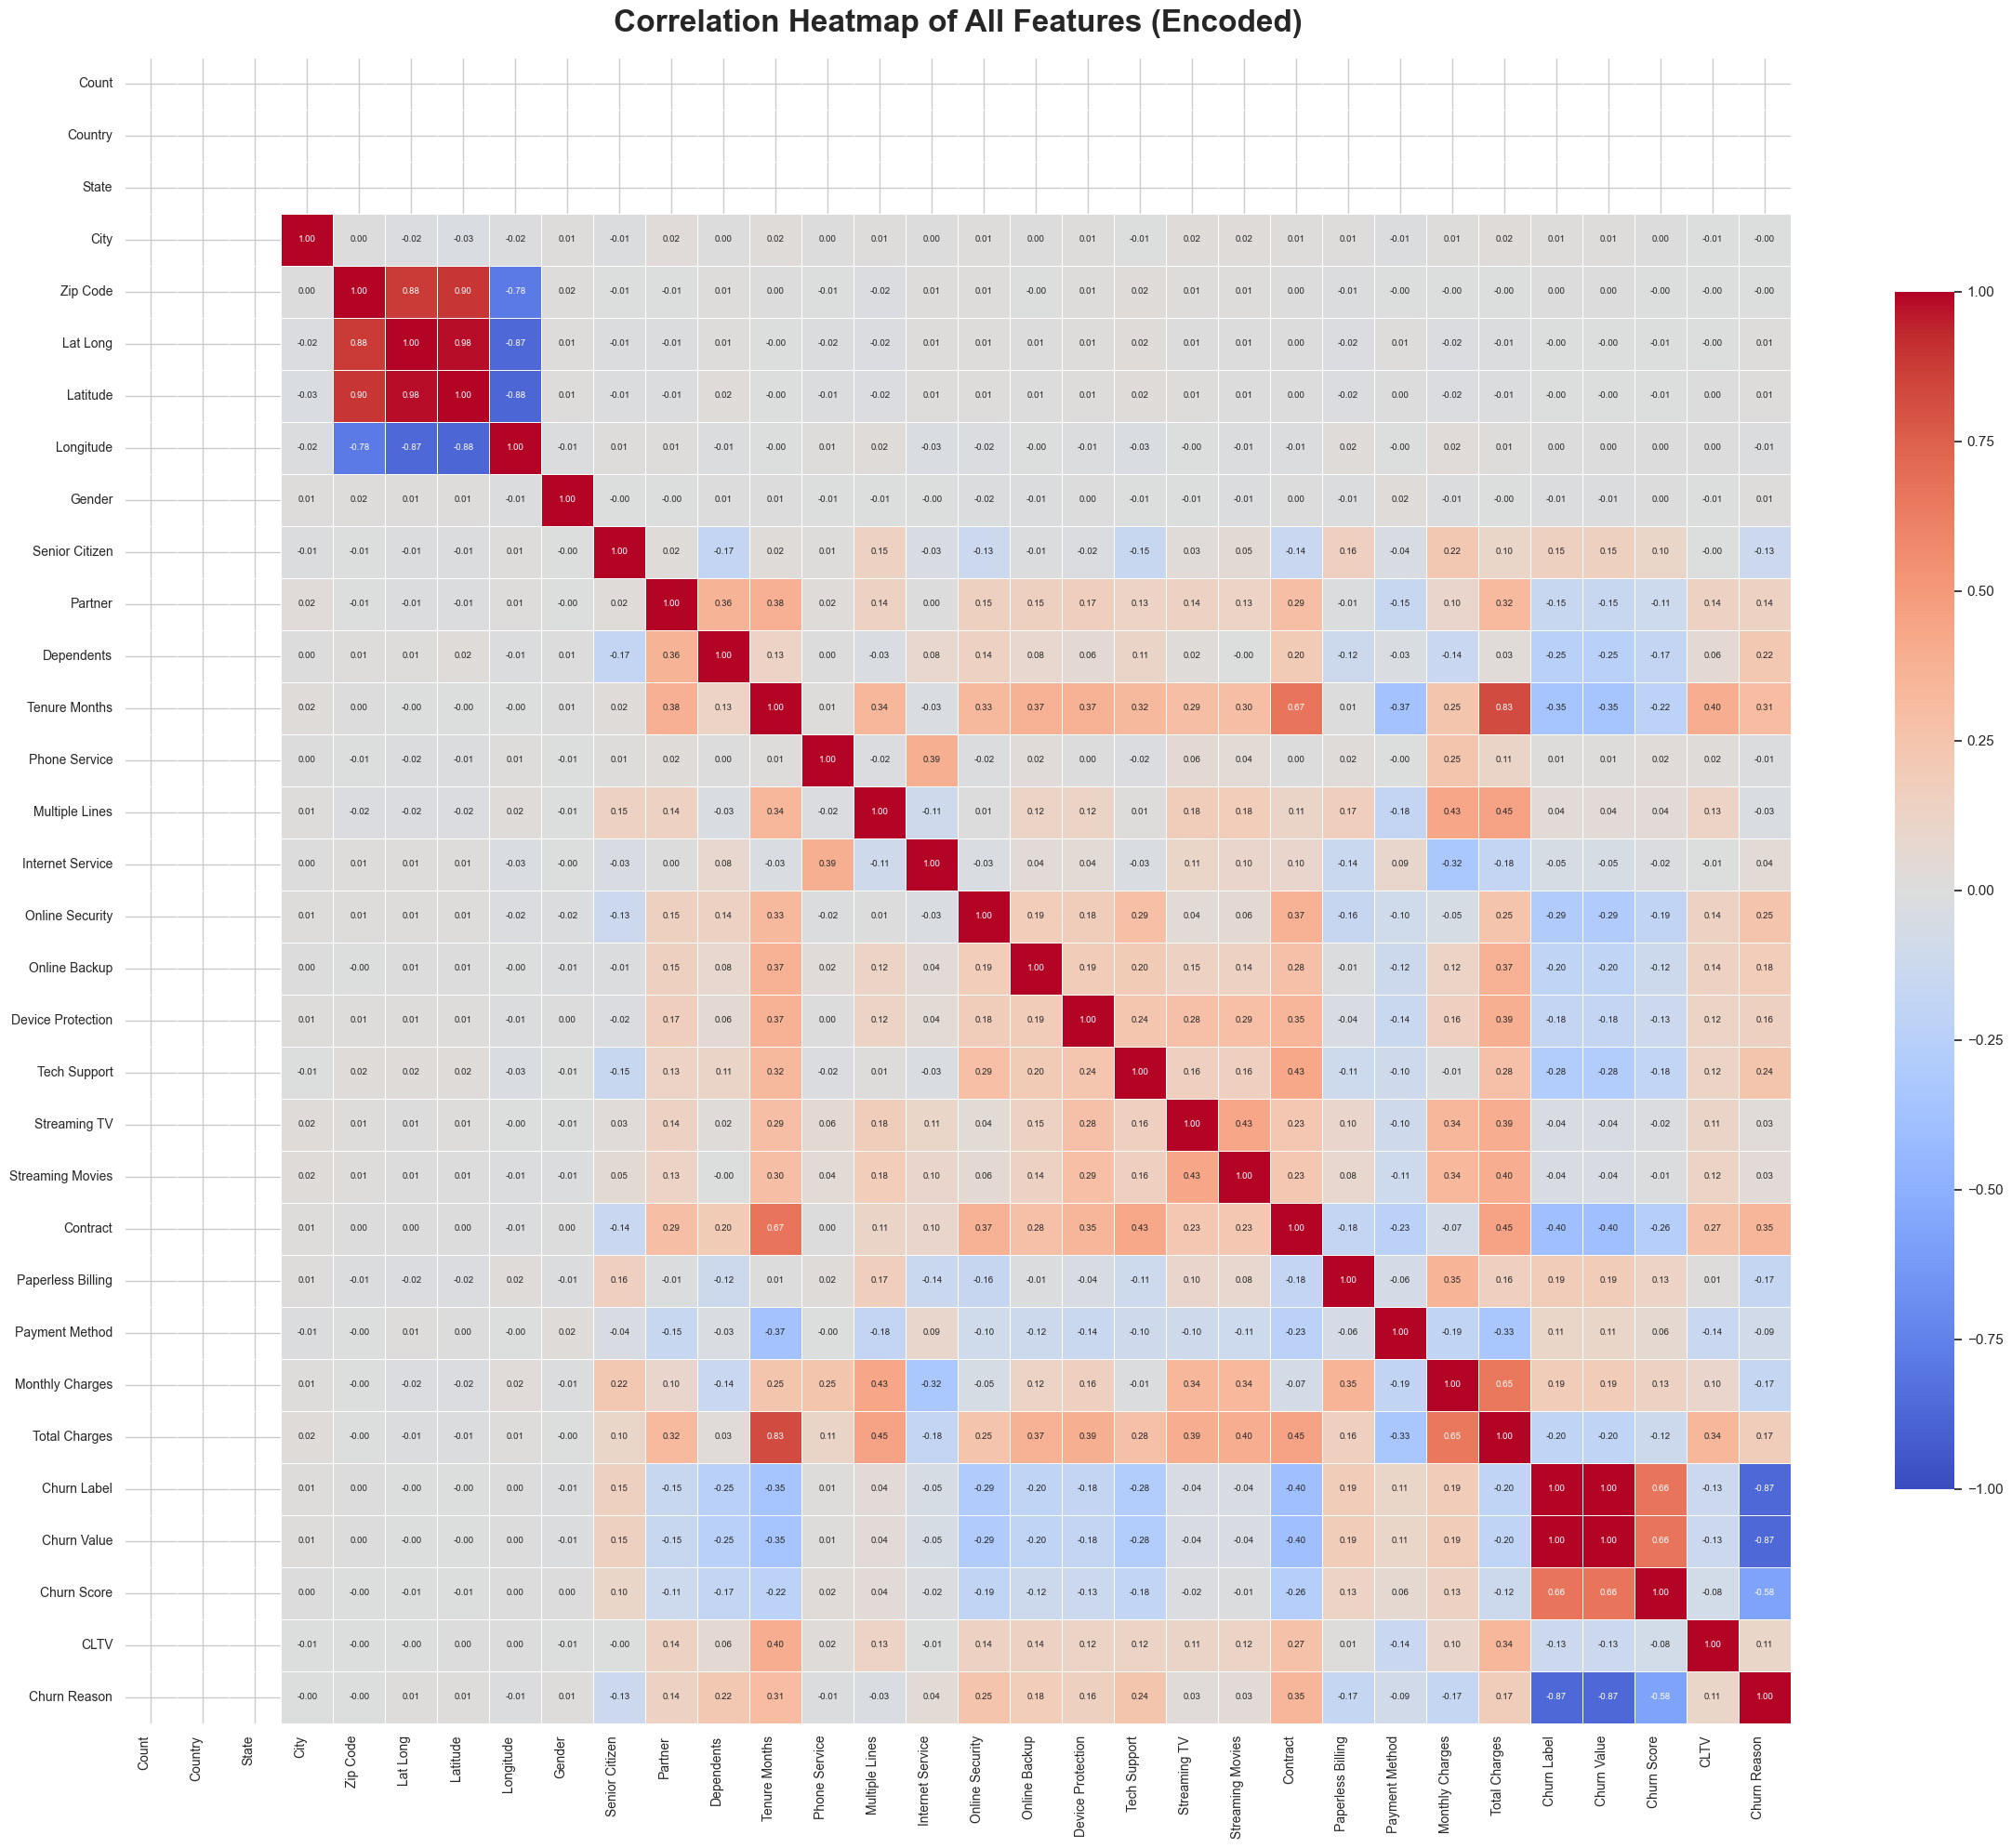

In [7]:
# 4. Vẽ Heatmap
plt.figure(figsize=(24, 20))

# Tính tương quan trực tiếp từ df đã được chuyển đổi
corr_matrix = df.corr()

# Mask nửa trên

# Vẽ heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .7}, annot_kws={"size": 7})

plt.title("Correlation Heatmap of All Features (Encoded)", fontsize=24, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
# 1. KIỂM TRA VÀ XÓA CỘT TRÙNG LẶP
duplicated_cols = df.columns[df.columns.duplicated()].tolist()
if duplicated_cols:
    print(f"🚨 Phát hiện các cột bị trùng tên: {duplicated_cols}")
    print("-> Đang tiến hành giữ lại cột đầu tiên và xóa các cột trùng...")
    # Lệnh này sẽ giữ lại cột xuất hiện đầu tiên và bỏ đi các cột trùng tên phía sau
    df = df.loc[:, ~df.columns.duplicated()].copy()
    print("✅ Đã dọn dẹp xong cột trùng!")
else:
    print("✅ Không có cột nào bị trùng tên.")

# 2. CHẠY LẠI LOGIC KIỂM TRA (Đã viết lại an toàn hơn)
print(f"\nKích thước dữ liệu hiện tại: {df.shape[0]} dòng, {df.shape[1]} cột")

if df.empty:
    print("🚨 CẢNH BÁO ĐỎ: DataFrame của bạn đã bị rỗng (0 dòng).")
else:
    # Lấy danh sách cột số
    numeric_cols = df.select_dtypes(include='number').columns
    null_counts = df[numeric_cols].isnull().sum()
    
    print("\nSố lượng giá trị NaN trong từng cột số:")
    print(null_counts)
    
    # SỬ DỤNG .items() ĐỂ ĐẢM BẢO AN TOÀN TUYỆT ĐỐI
    # Cách này sẽ lấy chính xác cặp (tên_cột, số_lượng_nan) dù có chuyện gì xảy ra
    for col, count in null_counts.items():
        if count == len(df):
            print(f"🚨 CẢNH BÁO: Cột '{col}' chứa 100% giá trị NaN. Không thể vẽ đồ thị cho cột này!")

✅ Không có cột nào bị trùng tên.

Kích thước dữ liệu hiện tại: 7043 dòng, 32 cột

Số lượng giá trị NaN trong từng cột số:
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64
